## Algorithm Of Colorimetry

## Import Libraries

In [3]:
import colour
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Sample Separation

In [18]:

#Carga de los datos
input_filename = ('samples/test-colores-14-03-26/test-colores-14-03-26.csv')
data = pd.read_csv(input_filename, low_memory=False)

#Extraer las longitudes de onda 'Wavelength (nm)'
wavelengths = data.iloc[1:, 0]

#Extraer las reflectancias de cada muestra 'Reflectances (%R)' - a partir de la columna 5 (índice 4)
reflectances = data.iloc[1:, 1::2]

#Unir todo en un nuevo DataFrame
master_data = pd.concat([wavelengths, reflectances], axis=1)
num_samples = master_data.shape[1] - 1

#Asignamos los nombres al DataFrame
new_columns = ['Wavelength (nm)'] + [f'Reflectance POS {i} (%R)' for i in range(num_samples)]
master_data.columns = new_columns

#Todo lo que sea texto (el reporte del final) se convertirá en NaN (Not a Number) y se elimina
master_data['Wavelength (nm)'] = pd.to_numeric(master_data['Wavelength (nm)'], errors='coerce')
master_data = master_data.dropna(subset=['Wavelength (nm)'])

#Guardar datos procesados
# Crear carpeta si no existe
os.makedirs("data-processed", exist_ok=True)
base_name = os.path.splitext(os.path.basename(input_filename))[0]
output_filename = f"data-processed/{base_name}_processed.csv"
master_data.to_csv(output_filename, index=False)
print(f'Archivo procesado guardado con nombre {output_filename}')


Archivo procesado guardado con nombre data-processed/test-colores-14-03-26_processed.csv


## View Data

## Raw Data

In [19]:
data.head()

,POS0,Unnamed: 1,POS1,Unnamed: 3,POS2,Unnamed: 5,POS3,Unnamed: 7,POS4,Unnamed: 9,...,Unnamed: 63,POS32,Unnamed: 65,POS33,Unnamed: 67,POS34,Unnamed: 69,POS35,Unnamed: 71,Unnamed: 72
0,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,...,%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,NaN
1,1000.01416,14.88808823,1000.01416,15.1480999,1000.01416,15.76548386,1000.01416,15.81099033,1000.01416,15.78507233,...,15.81517601,1000.01416,16.16860008,1000.01416,16.07276154,1000.01416,16.15141106,1000.01416,15.98187256,NaN
2,999.0076904,15.06511974,999.0076904,15.08710861,999.0076904,15.79427528,999.0076904,16.02326393,999.0076904,15.70754051,...,15.87104988,999.0076904,16.09524727,999.0076904,15.84238434,999.0076904,15.89756489,999.0076904,16.14155769,NaN
3,998.0006714,14.96455479,998.0006714,15.11015034,998.0006714,15.55130291,998.0006714,15.80410004,998.0006714,15.55187416,...,15.89643192,998.0006714,16.19909286,998.0006714,16.11365318,998.0006714,16.01399612,998.0006714,16.029953,NaN
4,996.993042,14.73498631,996.993042,14.80087662,996.993042,15.65877628,996.993042,15.57874107,996.993042,15.54496002,...,15.75456429,996.993042,15.70850468,996.993042,16.00553131,996.993042,15.86763287,996.993042,15.87128067,NaN


## Processing Data

In [20]:
master_data.head()

,Wavelength (nm),Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),...,Reflectance POS 26 (%R),Reflectance POS 27 (%R),Reflectance POS 28 (%R),Reflectance POS 29 (%R),Reflectance POS 30 (%R),Reflectance POS 31 (%R),Reflectance POS 32 (%R),Reflectance POS 33 (%R),Reflectance POS 34 (%R),Reflectance POS 35 (%R)
1,1000.014160,14.88808823,15.1480999,15.76548386,15.81099033,15.78507233,16.09719658,15.12008476,15.14489079,15.76624203,...,15.67419052,15.90722942,15.95839882,15.85105515,16.00347328,15.81517601,16.16860008,16.07276154,16.15141106,15.98187256
2,999.007690,15.06511974,15.08710861,15.79427528,16.02326393,15.70754051,16.22003555,15.07139397,14.88849354,15.71382427,...,15.77802467,15.84918213,16.09037399,15.94570923,16.02931023,15.87104988,16.09524727,15.84238434,15.89756489,16.14155769
3,998.000671,14.96455479,15.11015034,15.55130291,15.80410004,15.55187416,16.37279129,15.14738083,15.07589245,15.8131752,...,15.94757462,15.74559784,16.265728,15.85299969,15.77164078,15.89643192,16.19909286,16.11365318,16.01399612,16.029953
4,996.993042,14.73498631,14.80087662,15.65877628,15.57874107,15.54496002,16.19000816,15.15033436,14.95737457,15.63594341,...,15.89045334,15.94481754,16.10968018,15.71434116,15.91796398,15.75456429,15.70850468,16.00553131,15.86763287,15.87128067
5,995.984802,14.88867092,14.76780319,15.54154301,15.77867699,15.47938538,16.1899662,15.08384514,14.88455963,15.68521309,...,15.79159069,15.81272221,15.86397171,15.7818203,15.76531696,15.65077782,15.7442255,15.6688261,16.03845596,15.79868221


### Visualization of Spectrum

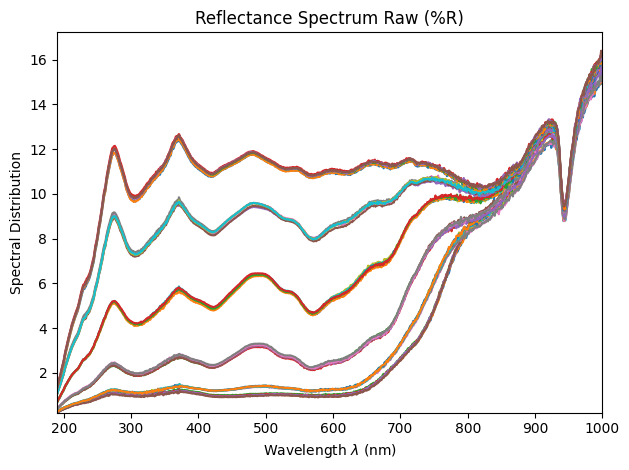

Gráfico guardado en: graphics/test-grises-14-03-26.svg


In [4]:
#Cargar datos
processed_file = 'data-processed/test-grises-14-03-26_processed.csv'
data_view = pd.read_csv(processed_file)

#Organizar los datos de forma ascendente
data_view = data_view.set_index('Wavelength (nm)')
data_view = data_view.sort_index()

#Crear el objeto con datos crudos (0-100)
msds_raw = colour.MultiSpectralDistributions(data_view)

#Graficar los espectros crudos
fig, ax = colour.plotting.plot_multi_sds(
    msds_raw,
    title='Reflectance Spectrum Raw (%R)',
    legend=False
)

#Guardar en SVG con el mismo nombre sin "_processed"
os.makedirs('graphics', exist_ok=True)
base_name = os.path.splitext(os.path.basename(processed_file))[0].replace('_processed', '')
svg_path = f'graphics/{base_name}.svg'
fig.savefig(svg_path, format='svg', bbox_inches='tight')
print(f'Gráfico guardado en: {svg_path}')

plt.show()

## Preprocessing Data to Color Parameters

### Negative Reflectance

In [9]:
# Cargar datos procesados
data_processed = pd.read_csv('data-processed/test-grises-14-03-26_processed.csv')

# Verificar si existen valores negativos
data_negatives = (data_processed < 0).stack()
data_negatives = data_negatives[data_negatives]

# Convertirlo a un Dataframe
data_negatives = data_negatives.reset_index()
data_negatives.columns = ['Row', 'Col', 'Is_negative']

# Usamos comprensiones de lista con .at para mayor seguridad y evitar el error de apply
# Obtener el valor negativo de Reflectancia
data_negatives['Reflectance (%R)'] = [
    data_processed.at[r, c] for r, c in zip(data_negatives['Row'], data_negatives['Col'])
]

# Obtener el valor de la longitud de onda en donde hubo reflectancia negativa
wavelength_col = data_processed.columns[0]
data_negatives['Wavelength (nm)'] = [
    data_processed.at[r, wavelength_col] for r in data_negatives['Row']
]

print(data_negatives)

Empty DataFrame
Columns: [Row, Col, Is_negative, Reflectance (%R), Wavelength (nm)]
Index: []


In [10]:
data_processed = pd.read_csv('data-processed/test-grises-14-03-26_processed.csv')

### Set negative reflectance values to zero and normalize

In [11]:
#Crear una copia de los datos procesados
data_normalized = data_processed.copy(deep=True)
data_normalized = data_normalized.set_index('Wavelength (nm)')
data_normalized = data_normalized.sort_index(ascending=True)

#Cambiar los valores negativos a 0
data_normalized[data_normalized < 0] = 0

#Normalizar los % de reflectancia entre 100 (Factor de 0 a 1)
data_normalized = data_normalized / 100.0

In [12]:
data_normalized

,Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),Reflectance POS 9 (%R),...,Reflectance POS 26 (%R),Reflectance POS 27 (%R),Reflectance POS 28 (%R),Reflectance POS 29 (%R),Reflectance POS 30 (%R),Reflectance POS 31 (%R),Reflectance POS 32 (%R),Reflectance POS 33 (%R),Reflectance POS 34 (%R),Reflectance POS 35 (%R)
Wavelength (nm),,,,,,,,,,,,,,,,,,,,,
190.015442,0.002298,0.002410,0.002445,0.002362,0.002245,0.002154,0.002547,0.002587,0.002624,0.002532,...,0.010748,0.010861,0.010654,0.010472,0.012955,0.012673,0.013369,0.013674,0.013372,0.013474
191.005661,0.002518,0.002541,0.002638,0.002557,0.002476,0.002469,0.002913,0.002878,0.002891,0.003063,...,0.011549,0.011669,0.011186,0.011391,0.013673,0.013755,0.014255,0.014497,0.014142,0.014276
191.995804,0.002655,0.002728,0.002765,0.002867,0.002577,0.002579,0.002894,0.002897,0.003237,0.003064,...,0.012815,0.013081,0.012531,0.012442,0.015311,0.014998,0.015701,0.016172,0.015866,0.015681
192.985886,0.002729,0.002825,0.002864,0.002827,0.002643,0.002647,0.003151,0.003168,0.003189,0.003290,...,0.013395,0.013761,0.013064,0.013108,0.016196,0.015905,0.016601,0.017126,0.016738,0.016759
194.015488,0.002967,0.003051,0.003061,0.003034,0.002968,0.002814,0.003382,0.003320,0.003468,0.003374,...,0.014390,0.014718,0.014050,0.013988,0.017315,0.017000,0.017700,0.018282,0.017793,0.017907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995.984802,0.149099,0.149559,0.153024,0.155127,0.155045,0.156098,0.150182,0.151869,0.153693,0.155102,...,0.157933,0.159859,0.157866,0.157825,0.157235,0.159898,0.159796,0.159576,0.158724,0.160464
996.993042,0.148916,0.149244,0.154588,0.153898,0.155934,0.155273,0.150003,0.152981,0.156698,0.156643,...,0.160123,0.160475,0.159906,0.159452,0.160108,0.158099,0.158920,0.161794,0.161448,0.161221
998.000671,0.149432,0.150380,0.153571,0.154469,0.156212,0.155834,0.151032,0.150369,0.155378,0.158005,...,0.161501,0.157413,0.159727,0.158615,0.159087,0.159732,0.161470,0.161152,0.159970,0.164054


### Create MultiSpectralDistribution and XYZ Values

In [13]:
#Crear objeto
msds = colour.MultiSpectralDistributions(data_normalized)

#Verificamos la dimension y la forma de los espectros (Valor Max, Valor Min, Saltos)
print(msds.shape)
print(msds.domain[:5])

#Definimos nueva forma de nuestro espectro en el rango visible
shape = colour.SpectralShape(360, 750, 1)

#Interpolacion de los espectros para que los saltos sean de 1nm
msds = msds.align(shape)

#Cargar estandares de la CIE
cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
illuminant = colour.SDS_ILLUMINANTS['D65']

#Calculo XYZ
XYZ = colour.msds_to_XYZ(msds, cmfs, illuminant)

#Visualizar valores XYZ calculados
print("Dimensión de XYZ:", XYZ.shape)
print("Valores XYZ:\n", XYZ)

(190.0154419, 1000.01416, 0.9638060999999993)
[ 190.0154419  191.005661   191.9958038  192.9858856  194.0154877]
Dimensión de XYZ: (36, 3)
Valores XYZ:
 [[  0.97010935   1.00666615   1.06283758]
 [  0.96288523   0.99968119   1.05384813]
 [  1.01645858   1.05641274   1.11301713]
 [  0.97979642   1.0202718    1.07224831]
 [  0.96184984   1.00440144   1.04842809]
 [  0.93020108   0.9705001    1.01505915]
 [  1.21709694   1.266796     1.37799998]
 [  1.22382111   1.27320753   1.3820385 ]
 [  1.24432052   1.29881722   1.40753877]
 [  1.23456385   1.28575799   1.39174563]
 [  1.25432837   1.30877009   1.41604233]
 [  1.24318827   1.29917411   1.40356584]
 [  2.46795743   2.60315357   2.96715311]
 [  2.39690607   2.53776476   2.94282417]
 [  2.42891252   2.57855758   2.97960157]
 [  2.44123519   2.59123008   2.99285459]
 [  2.46297512   2.61297443   3.04279821]
 [  2.52228167   2.67599914   3.09037907]
 [  5.19044375   5.46378943   6.16468744]
 [  5.18701965   5.47039025   6.21265029]
 [  5.1

## Calculate CIELab (L* a* b*)

In [14]:
#Definir punto blanco para el iluminante D65
illuminant_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']

#Usamos los valores XYZ para calcular CIELab
Lab = colour.XYZ_to_Lab(XYZ, illuminant=illuminant_xy)

#Visualizar valores Lab calculados
print('Valores CIELab calculados.')
print("Valores (L, a, b):\n", Lab)

Valores CIELab calculados.
Valores (L, a, b):
 [[  1.00257187e+02   2.31426429e+00   2.06154986e+00]
 [  9.99876713e+01   2.22324276e+00   2.15775440e+00]
 [  1.02141514e+02   2.08516458e+00   2.23621886e+00]
 [  1.00778605e+02   1.73687656e+00   2.37675223e+00]
 [  1.00169940e+02   1.25754242e+00   2.81173188e+00]
 [  9.88479333e+01   1.38849398e+00   2.65015661e+00]
 [  1.09514399e+02   1.94953199e+00   8.44240550e-02]
 [  1.09725795e+02   2.03641533e+00   2.37781861e-01]
 [  1.10563167e+02   1.44740683e+00   3.57884931e-01]
 [  1.10137552e+02   1.84858912e+00   4.41937090e-01]
 [  1.10885631e+02   1.51998078e+00   4.76018600e-01]
 [  1.10574759e+02   1.23148754e+00   5.83035909e-01]
 [  1.43572452e+02  -5.77354373e-01  -4.21071889e+00]
 [  1.42225002e+02  -1.42876096e+00  -5.76834915e+00]
 [  1.43068286e+02  -2.04769332e+00  -5.47007013e+00]
 [  1.43328444e+02  -2.01498653e+00  -5.43564014e+00]
 [  1.43772872e+02  -1.90400759e+00  -6.21908533e+00]
 [  1.45047250e+02  -1.92836122e+00

## Calculate CIELCh ()

## Visualization of XYZ in sRGB

Muestras fuera de gamut sRGB: 1682 de 1682


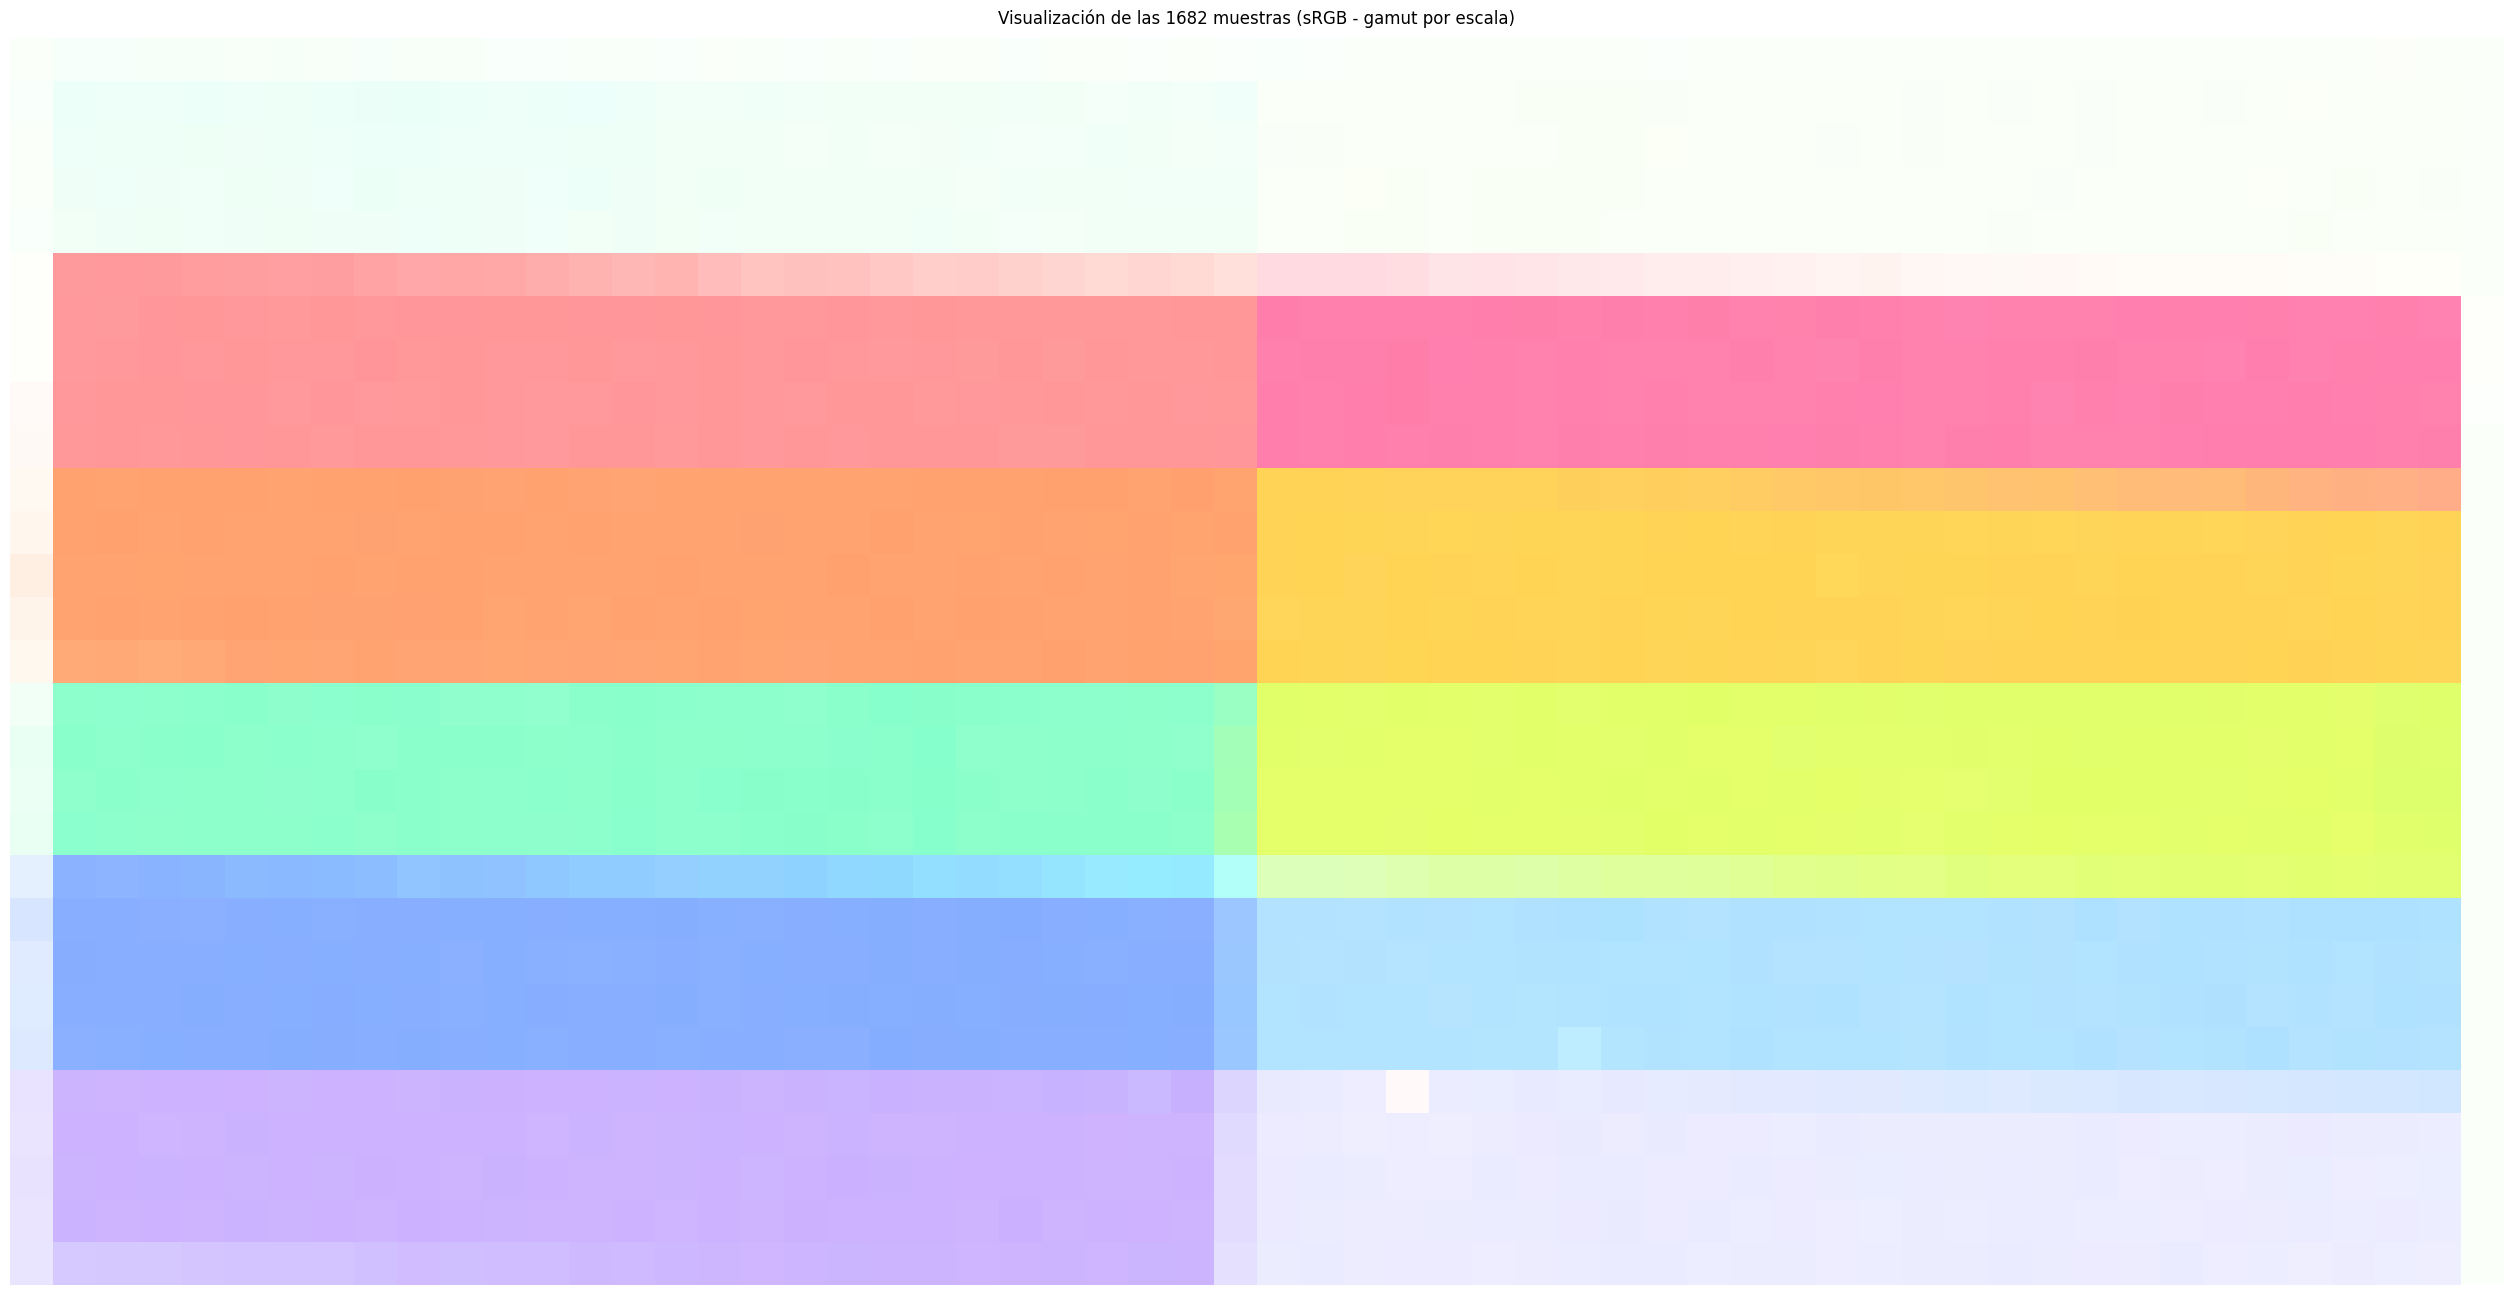

In [23]:

# Convertimos los tristimulos XYZ a sRGB
RGB = colour.XYZ_to_sRGB(XYZ, illuminant=illuminant_xy)

# ── Gamut mapping por escala (preserva tono, reduce saturación) ──────────────
RGB_mapped = np.clip(RGB, 0, None)
max_per_sample = RGB_mapped.max(axis=1, keepdims=True)
scale = np.where(max_per_sample > 1, max_per_sample, 1.0)
RGB_mapped = RGB_mapped / scale

n = RGB_mapped.shape[0]
cols = 58
rows = int(np.ceil(n / cols))

# Rellenar hasta completar la rejilla (fila por fila)
pad = rows * cols - n
if pad > 0:
    RGB_mapped = np.vstack([RGB_mapped, np.ones((pad, 3))])  # relleno blanco

# Reshape a imagen (rows, cols, 3) — fila por fila, sin rotación
img = RGB_mapped.reshape(rows, cols, 3)
img = np.fliplr(img)  # espejo horizontal

print(f"Muestras fuera de gamut sRGB: {(RGB.max(axis=1) > 1).sum()} de {n}")

fig, ax = plt.subplots(figsize=(cols * 0.45, rows * 0.45))
ax.imshow(img, aspect='equal', interpolation='nearest')
ax.set_title(f'Visualización de las {n} muestras (sRGB - gamut por escala)', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()
